In [1]:
# ============================================
# SECCIÓN 8. COMPARACIÓN: CLUSTERING JERÁRQUICO VS K-MEANS
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import adjusted_rand_score, confusion_matrix

# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
# --------------------------------------------------
# 0. Comprobación básica
# Se asume que ya existen:
# df_hc  -> con columna "cluster_hierarquico"
# df_km  -> con columna "cluster_kmeans"
# y que ambos provienen del mismo dataset filtrado
# --------------------------------------------------

df_hc = pd.read_csv("resultados_clustering_jerarquico.csv")
df_km = pd.read_csv("resultados_clustering_kmeans.csv")


In [4]:
# Si quieres garantizar alineación exacta por índice:
df_comp = pd.DataFrame(index=df_hc.index)
df_comp["species"] = df_hc["species"]
df_comp["cluster_hierarquico"] = df_hc["cluster_hierarquico"]
df_comp["cluster_kmeans"] = df_km.loc[df_hc.index, "cluster_kmeans"]

# Si df_hc ya tiene CP1 y CP2 puedes reutilizarlos
if "CP1" in df_hc.columns and "CP2" in df_hc.columns:
    df_comp["CP1"] = df_hc["CP1"]
    df_comp["CP2"] = df_hc["CP2"]

In [5]:
# --------------------------------------------------
# 1. Frecuencia por método
# --------------------------------------------------
print("Frecuencia de clusters jerárquicos:")
display(df_comp["cluster_hierarquico"].value_counts().sort_index())

print("Frecuencia de clusters K-means:")
display(df_comp["cluster_kmeans"].value_counts().sort_index())

Frecuencia de clusters jerárquicos:


cluster_hierarquico
1    123
2     57
3    162
Name: count, dtype: int64

Frecuencia de clusters K-means:


cluster_kmeans
1     87
2    123
3    132
Name: count, dtype: int64

In [6]:
# --------------------------------------------------
# 2. Tabla cruzada entre métodos
# --------------------------------------------------
print("Tabla cruzada: cluster jerárquico vs cluster K-means")
tabla_metodos = pd.crosstab(
    df_comp["cluster_hierarquico"],
    df_comp["cluster_kmeans"],
    margins=True
)
display(tabla_metodos)

Tabla cruzada: cluster jerárquico vs cluster K-means


cluster_kmeans,1,2,3,All
cluster_hierarquico,,,,
1,0,123,0,123
2,57,0,0,57
3,30,0,132,162
All,87,123,132,342


In [7]:
# --------------------------------------------------
# 3. Tabla cruzada de cada método contra species
# --------------------------------------------------
print("Tabla cruzada: cluster jerárquico vs species")
tabla_hc_species = pd.crosstab(
    df_comp["cluster_hierarquico"],
    df_comp["species"],
    margins=True
)
display(tabla_hc_species)

print("Tabla cruzada: cluster K-means vs species")
tabla_km_species = pd.crosstab(
    df_comp["cluster_kmeans"],
    df_comp["species"],
    margins=True
)
display(tabla_km_species)

Tabla cruzada: cluster jerárquico vs species


species,Adelie,Chinstrap,Gentoo,All
cluster_hierarquico,,,,
1,0,0,123,123
2,0,57,0,57
3,151,11,0,162
All,151,68,123,342


Tabla cruzada: cluster K-means vs species


species,Adelie,Chinstrap,Gentoo,All
cluster_kmeans,,,,
1,24,63,0,87
2,0,0,123,123
3,127,5,0,132
All,151,68,123,342


In [8]:
# --------------------------------------------------
# 4. Índice ARI (Adjusted Rand Index)
# Mide similitud entre ambos agrupamientos
# --------------------------------------------------
ari_hc_km = adjusted_rand_score(
    df_comp["cluster_hierarquico"],
    df_comp["cluster_kmeans"]
)

print(f"Adjusted Rand Index entre clustering jerárquico y K-means: {ari_hc_km:.4f}")

Adjusted Rand Index entre clustering jerárquico y K-means: 0.7894


In [9]:
# --------------------------------------------------
# 5. ARI contra species codificada
# Sirve para evaluar qué método se parece más a las especies
# --------------------------------------------------
species_codes = df_comp["species"].astype("category").cat.codes

ari_hc_species = adjusted_rand_score(species_codes, df_comp["cluster_hierarquico"])
ari_km_species = adjusted_rand_score(species_codes, df_comp["cluster_kmeans"])

print(f"ARI entre clustering jerárquico y species: {ari_hc_species:.4f}")
print(f"ARI entre K-means y species: {ari_km_species:.4f}")

ARI entre clustering jerárquico y species: 0.9159
ARI entre K-means y species: 0.7928


In [10]:
# --------------------------------------------------
# 6. Perfil medio de variables por método
# --------------------------------------------------
vars_numericas = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

# Añadimos variables numéricas desde df_hc
for var in vars_numericas:
    df_comp[var] = df_hc[var]

print("Perfil medio por cluster jerárquico:")
perfil_hc = (
    df_comp.groupby("cluster_hierarquico")[vars_numericas]
    .mean()
    .round(2)
)
display(perfil_hc)

print("Perfil medio por cluster K-means:")
perfil_km = (
    df_comp.groupby("cluster_kmeans")[vars_numericas]
    .mean()
    .round(2)
)
display(perfil_km)

Perfil medio por cluster jerárquico:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster_hierarquico,,,,
1,47.50,14.98,217.19,"5,076.02"
2,49.75,18.60,197.11,"3,810.09"
3,39.15,18.29,189.90,"3,675.77"


Perfil medio por cluster K-means:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster_kmeans,,,,
1,47.53,18.76,196.90,"3,902.01"
2,47.50,14.98,217.19,"5,076.02"
3,38.21,18.11,188.40,"3,584.66"


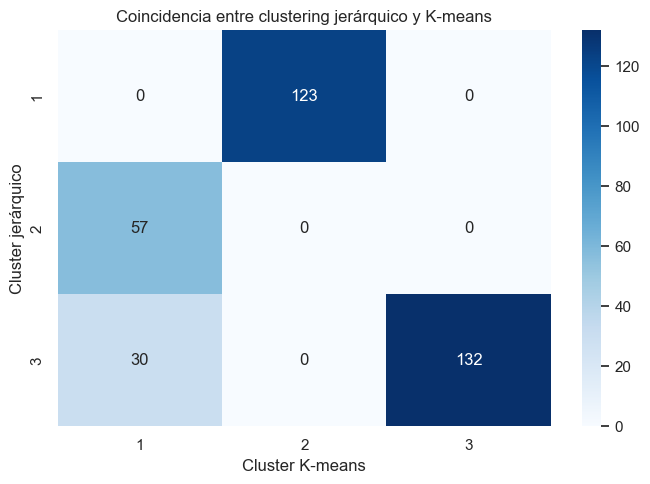

In [11]:
# --------------------------------------------------
# 7. Heatmap de coincidencia entre métodos
# --------------------------------------------------
tabla_sin_total = pd.crosstab(
    df_comp["cluster_hierarquico"],
    df_comp["cluster_kmeans"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    tabla_sin_total,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Coincidencia entre clustering jerárquico y K-means")
plt.xlabel("Cluster K-means")
plt.ylabel("Cluster jerárquico")
plt.tight_layout()
plt.show()

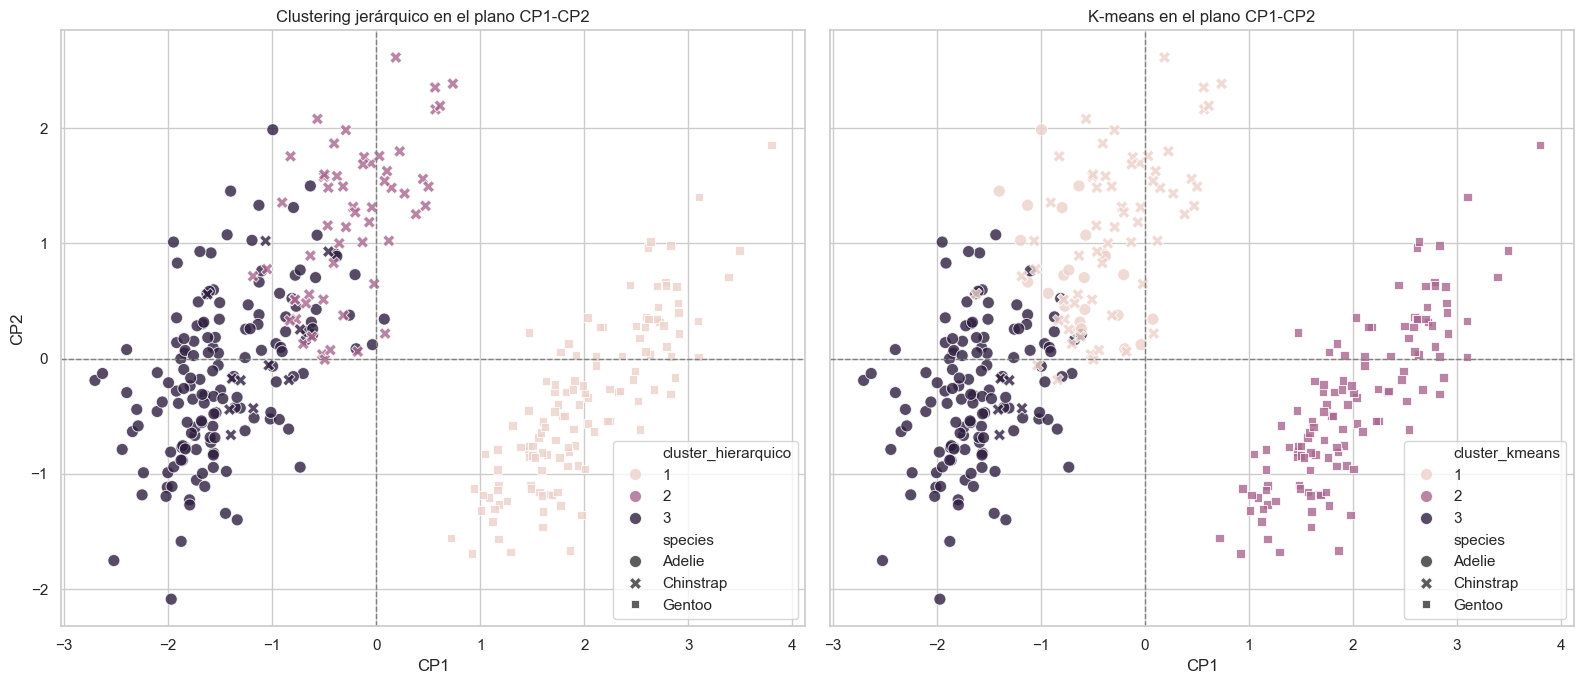

In [12]:
# --------------------------------------------------
# 8. Visualización comparativa en el plano CP1-CP2
# --------------------------------------------------
if "CP1" in df_comp.columns and "CP2" in df_comp.columns:
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

    sns.scatterplot(
        data=df_comp,
        x="CP1",
        y="CP2",
        hue="cluster_hierarquico",
        style="species",
        s=75,
        alpha=0.8,
        ax=axes[0]
    )
    axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[0].axvline(0, color="gray", linestyle="--", linewidth=1)
    axes[0].set_title("Clustering jerárquico en el plano CP1-CP2")
    axes[0].set_xlabel("CP1")
    axes[0].set_ylabel("CP2")

    sns.scatterplot(
        data=df_comp,
        x="CP1",
        y="CP2",
        hue="cluster_kmeans",
        style="species",
        s=75,
        alpha=0.8,
        ax=axes[1]
    )
    axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[1].axvline(0, color="gray", linestyle="--", linewidth=1)
    axes[1].set_title("K-means en el plano CP1-CP2")
    axes[1].set_xlabel("CP1")
    axes[1].set_ylabel("CP2")

    plt.tight_layout()
    plt.show()

In [13]:
# --------------------------------------------------
# 9. Observaciones con desacuerdo entre métodos
# --------------------------------------------------
# Como las etiquetas pueden estar permutadas entre métodos,
# este bloque es descriptivo y no definitivo.
df_comp["mismo_label"] = (
    df_comp["cluster_hierarquico"] == df_comp["cluster_kmeans"]
)

print("Número de observaciones con la misma etiqueta numérica en ambos métodos:")
print(df_comp["mismo_label"].sum())

print("Número de observaciones con etiqueta numérica distinta en ambos métodos:")
print((~df_comp["mismo_label"]).sum())

Número de observaciones con la misma etiqueta numérica en ambos métodos:
132
Número de observaciones con etiqueta numérica distinta en ambos métodos:
210


In [14]:
# --------------------------------------------------
# 10. Resumen comparativo automático
# --------------------------------------------------
resumen_comparacion = pd.DataFrame({
    "Métrica": [
        "ARI jerárquico vs K-means",
        "ARI jerárquico vs species",
        "ARI K-means vs species"
    ],
    "Valor": [
        ari_hc_km,
        ari_hc_species,
        ari_km_species
    ]
}).round(4)

print("Resumen comparativo de métricas:")
display(resumen_comparacion)

Resumen comparativo de métricas:


,Métrica,Valor
0,ARI jerárquico vs K-means,0.79
1,ARI jerárquico vs species,0.92
2,ARI K-means vs species,0.79
